# QF 627 Programming and Computational Finance
## Problem Set `5` | `In Progress` Part `2`

> Hi Team! 👋

> The current problem set has two main parts. Questions 1 through 7 are scenario-based, giving you a taste of day-to-day operations as a buy-side Quant in the field. Questions 8 through 12 will help you explore a technical indicator for detecting momentum signals—namely, the Moving Average Convergence Divergence (MACD).

> As always, these questions have been carefully designed to guide your optimal learning. While you read and answer the questions, you’ll be able to feel my affection for you all 🙌

> Enjoy 🤗

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 Questions 1 through 7 are based on the following scenario. After reading it, please respond to the associated sub-questions.

> Suppose that you've been appointed as a Quantitative Researcher in the process-driven investing division of a leading hedge fund. As part of your onboarding challenge, you are handed data (`alphas.csv`) for three experimental trading models, codenamed Alphas A, B, and C. These models, each initiated with a capital of 100K, demonstrate nearly identical Sharpe ratios across a span of 1120 trading days. Intrigued by this uniformity yet aware of the Sharpe ratio's shortcomings, you embark on a journey to dissect the Alphas' performance through a multifaceted quantitative lens.

In [3]:
alphas =\
(
    pd
    .read_csv("alphas.csv",
              index_col = 0,
              parse_dates = True)
)

alphas

,Alphas A,Alphas B,Alphas C
2019-05-28,100.000000,100.000000,100.000000
2019-05-29,100.562415,101.991696,100.733993
2019-05-30,98.903615,104.527038,100.568916
2019-05-31,101.046406,107.799053,99.186270
2019-06-03,101.649234,107.750748,101.323467
...,...,...,...
2023-09-06,87.171517,85.212876,88.864669
2023-09-07,87.770479,85.143390,87.782382
2023-09-08,88.204118,84.376805,87.391530
2023-09-11,88.475733,85.531184,86.241478


### <font color = blue> 👉 Question 1</font>. Sharpe Ratio Diagnostics:

- Given the daily return series for Alphas A, B, and C:

- Derive the annualized Sharpe ratio for each Alpha, with the industry-standard assumption of 252 trading days per annum. In light of these findings, how might you reconsider the perceived risk-adjusted returns of these models?

In [4]:
def calculate_sharpe_ratio(daily_returns):
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std()

### <font color = red> Answer 1 is presented in the cell below: </font>

In [5]:
alphas.columns

Index(['Alphas A', 'Alphas B', 'Alphas C'], dtype='object')

In [42]:
answer_1 = alphas
[{key: calculate_sharpe_ratio(alphas[key].pct_change())} for key in alphas.columns]

[{'Alphas A': -0.057912193325420726},
 {'Alphas B': -0.06783329116885627},
 {'Alphas C': -0.06277900764250023}]

### <font color = blue> 👉 Question 2</font>. Trajectory of Cumulative Returns:
    
- Visualize and compare the cumulative returns of each Alpha, using both lets-plot and matplotlib libraries.

In [6]:
alphas_returns =\
(
    np
    .log(
        alphas 
        /
        alphas.shift(1)
    )
)

alphas_cumulative_returns = alphas_returns.cumsum().apply(np.exp)

### <font color = red> Answer 2 is presented in the cell below: </font>

<Axes: >

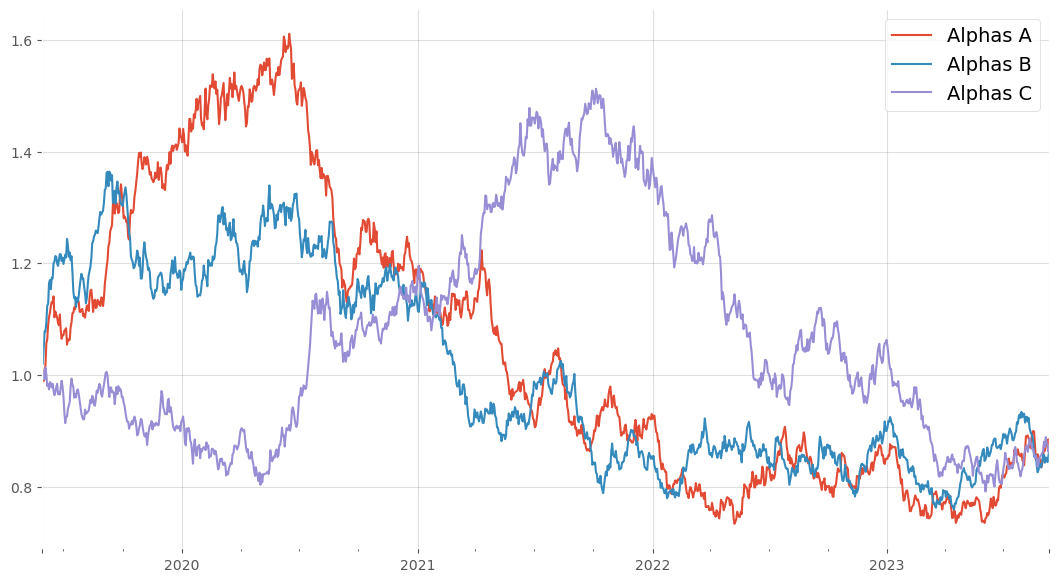

In [7]:
alphas_cumulative_returns.plot(figsize = [13, 7 ]
                              )

### <font color = blue> 👉 Question 3</font>. Cumulative Returns Over a 1120-Day Horizon:

- Extrapolate the cumulative returns for each Alpha over this period.
  
- When evaluating based on the Compound Annual Growth Rate (CAGR), how do these Alphas stack up against one another?

### Elegant Coding

- Scalable
- Robust
- Efficient 

In [8]:
def calculate_cagr(cumulative_returns):
    cumulative_returns = cumulative_returns.dropna()
    d = (cumulative_returns.index[-1] - cumulative_returns.index[0]).days
    cagr = (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (365.0 / d) - 1
    return cagr

### <font color = red> Answer 3 is presented in the cell below: </font>

In [20]:
%whos

Variable                    Type         Data/Info
--------------------------------------------------
alphas                      DataFrame                  Alphas A   <...>\n[1121 rows x 3 columns]
alphas_cumulative_returns   DataFrame                Alphas A  Alp<...>\n[1121 rows x 3 columns]
alphas_returns              DataFrame                Alphas A  Alp<...>\n[1121 rows x 3 columns]
calculate_cagr              function     <function calculate_cagr at 0x17f708ee0>
calculate_sharpe_ratio      function     <function calculate_sharpe_ratio at 0x16dbe90d0>
dt                          module       <module 'datetime' from '<...>b/python3.9/datetime.py'>
mpl                         module       <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np                          module       <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
pd                          module       <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
pdr                         module       <modul

In [9]:
answer_3 = [
    {f"{key} CAGR": calculate_cagr(alphas_cumulative_returns[key])}
    for key in alphas_cumulative_returns.columns
]

### <font color = blue> 👉 Question 4</font>. Maximum Draw-down (MDD):

- Assess the Maximum Drawdown (MDD) for each model within this time frame.

- Based on this assessment, which Alpha appears best equipped to withstand market downturns?

In [10]:
def calculate_drawdown_percent(cumulative_returns):
    max_gross_performance = cumulative_returns.cummax()
    drawdown = (max_gross_performance - cumulative_returns) / max_gross_performance
    return drawdown

In [11]:
%who

alphas	 alphas_cumulative_returns	 alphas_returns	 answer_3	 calculate_cagr	 calculate_drawdown_percent	 calculate_sharpe_ratio	 dt	 mpl	 
np	 pd	 pdr	 plt	 yf	 


### <font color = red> Answer 4 is presented in the cell below: </font>

In [12]:
answer_4 = [
    {f"{key} MDD": calculate_drawdown_percent(alphas_cumulative_returns[key]).max()}
    for key in alphas_cumulative_returns.columns
]

### <font color = blue> 👉 Question 5</font>. Examining Drawdown Duration:

- Analyze the longest drawdown durations for each strategy.

- Which of the Alphas seems to have the quickest recovery mechanism following a significant drawdown?

In [13]:
def calculate_longest_drawdown(cumulative_returns):
    drawdown = cumulative_returns.cummax() - cumulative_returns
    period = np.diff(np.append(drawdown[drawdown == 0].index, drawdown.index[-1: ]
                              )
                    )
    return period.max() / np.timedelta64(1, "D")

### <font color = red> Answer 5 is presented in the cell below: </font>

In [14]:
%who

alphas	 alphas_cumulative_returns	 alphas_returns	 answer_3	 answer_4	 calculate_cagr	 calculate_drawdown_percent	 calculate_longest_drawdown	 calculate_sharpe_ratio	 
dt	 mpl	 np	 pd	 pdr	 plt	 yf	 


In [15]:
answer_5 = [
    {f"{key} Longest DD": calculate_longest_drawdown(alphas_cumulative_returns[key])}
    for key in alphas_cumulative_returns.columns
]

### <font color = blue> 👉 Question 6</font>. Comprehensive Assessment of Strategy Performance:

- By synthesizing data from metrics such as the Sharpe ratio, cumulative returns trajectory, MDD, and drawdown duration, provide a well-rounded analysis of the three Alphas. 

- Rank and justify your recommendations based on your quantitative insights.

### <font color = red> Answer 6 is presented in the cell below: </font>

In [16]:
[calculate_sharpe_ratio(alphas[key].pct_change()) for key in alphas.columns]

[-0.057912193325420726, -0.06783329116885627, -0.06277900764250023]

In [17]:
dict_to_assess =\
{
    "Sharpe": [calculate_sharpe_ratio(alphas[key].pct_change()) for key in alphas.columns],
    "CAGR": [list(unpack.values())[0] for unpack in answer_3],
    "MDD": [list(unpack.values())[0] for unpack in answer_4],
    "Longest Drawdown": [list(unpack.values())[0] for unpack in answer_5]
}

In [18]:
df_to_assess = pd.DataFrame(dict_to_assess)
df_to_assess.index = ["Alpha A", "Alpha B", "Alpha C"]

df_to_assess

,Sharpe,CAGR,MDD,Longest Drawdown
Alpha A,-0.057912,-0.032403,0.544602,1183.0
Alpha B,-0.067833,-0.037295,0.443717,1463.0
Alpha C,-0.062779,-0.033521,0.476758,706.0


In [19]:
[list(unpack.values())[0] for unpack in answer_3]

[-0.03240277890861454, -0.03729517681949024, -0.03352056240207568]

In [20]:
### Ranking Method

df_for_ranking = pd.DataFrame(index = df_to_assess.index)

In [21]:
df_for_ranking

""
Alpha A
Alpha B
Alpha C


In [27]:
df_to_assess.columns

Index(['Sharpe', 'CAGR', 'MDD', 'Longest Drawdown'], dtype='object')

In [28]:
df_to_assess

,Sharpe,CAGR,MDD,Longest Drawdown
Alpha A,-0.057912,-0.032403,0.544602,1183.0
Alpha B,-0.067833,-0.037295,0.443717,1463.0
Alpha C,-0.062779,-0.033521,0.476758,706.0


In [25]:
for c in df_to_assess.columns[:]:
    df_for_ranking[c] =\
    (
        df_to_assess[c]
        .rank(axis = 0, # this is by default
              ascending = [False, False, True, True]
             )
    )

df_for_ranking # What if you have this question on the final assessment day?

,Sharpe,CAGR,MDD,Longest Drawdown
Alpha A,3.0,3.0,3.0,2.0
Alpha B,1.0,1.0,1.0,3.0
Alpha C,2.0,2.0,2.0,1.0


### Can we use dict?

In [26]:
dict_for_order =\
{
    "Sharpe": False,
    "CAGR": False,
    "MDD": True,
    "Longest Drawdown": True
}

In [29]:
test_df_to_assess = df_to_assess.copy()

### Pythonian-way of writing codes

In [30]:
for variable, order in dict_for_order.items():
    test_df_to_assess[variable] =\
    (
        df_to_assess[variable]
        .rank(ascending = order)
    )

In [31]:
test_df_to_assess

,Sharpe,CAGR,MDD,Longest Drawdown
Alpha A,1.0,1.0,3.0,2.0
Alpha B,3.0,3.0,1.0,3.0
Alpha C,2.0,2.0,2.0,1.0


In [32]:
test_df_to_assess["ranking_scores"] =\
(
    test_df_to_assess
    .sum(axis = 1)
)

test_df_to_assess

,Sharpe,CAGR,MDD,Longest Drawdown,ranking_scores
Alpha A,1.0,1.0,3.0,2.0,7.0
Alpha B,3.0,3.0,1.0,3.0,10.0
Alpha C,2.0,2.0,2.0,1.0,7.0


### <font color = blue> 👉 Question 7</font>. Reflecting on the Sharpe Ratio:

- Given the observed disparities in cumulative returns and MDD among the Alphas, even with similar Sharpe ratios, evaluate the effectiveness of relying solely on the Sharpe ratio.

- Can you propose additional or refined metrics to differentiate between Alphas with matching Sharpe values but varying performances in other critical areas?

### <font color = red> Answer 7 is presented in the cell below: </font>

## 👇 Questions 8 to 12 ask you to build, execute, and backtest a strategy based on one kind of momentum strategy called the `Moving Average Convergence Divergence` (MACD) crossover.

### <font color = blue> 👉 Question 8</font>. Let’s take a look at Apple (AAPL) as our security of interest, over the three-year period of 2015 through 2017.

#### Moving Average Convergence Divergence (`MACD`) is a lagging, trend-following momentum indicator reflecting the relationship between two moving averages of stock prices.

#### The strategy utilizes two indicators, the MACD and the MACD signal line:

- The MACD is defined as the `difference` between the `12`-day ***exponential*** moving average and the `26`-day exponential moving average.
- The MACD `signal line` is then defined as the `9`-day ***exponential*** moving average of the MACD.

### <font color = green> NOTE: The MACD crossover strategy is defined as:

- A `bullish` crossover arises when the MACD line turns `upward and crosses` beyond the MACD signal line.
- A `bearish` crossover arises when the MACD line turns `downward and crosses` under the MACD signal line.

### Visualize your buy and sell positions.

## Pitfall-laden approach

In [33]:
import datetime as dt

In [35]:
df_aapl =\
(
    yf
    .download("AAPL",
              start = dt.datetime(2015, 1, 1),
              end = dt.datetime(2017, 12, 31)
             )
    ["Close"]
)

df_aapl

[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2015-01-02,24.261044
2015-01-05,23.577572
2015-01-06,23.579794
2015-01-07,23.910435
2015-01-08,24.829130
...,...
2017-12-22,41.025661
2017-12-26,39.984833
2017-12-27,39.991856


#### 12-day Exponential Moving Averages (EMAs)

In [36]:
df_aapl["ema_12"] =\
(
    df_aapl["AAPL"]
    .ewm(min_periods = 12,
         span = 12)
    .mean()
)

#### 26-day Exponential Moving Averages (EMAs)

In [38]:
df_aapl["ema_26"] =\
(
    df_aapl["AAPL"]
    .ewm(span = 26,
         min_periods = 26)
    .mean()
)

df_aapl.head(2)

Ticker,AAPL,ema_12,ema_26
Date,,,
2015-01-02,24.261044,NaN,NaN
2015-01-05,23.577572,NaN,NaN


In [40]:
df_aapl["macd"] =\
(
    df_aapl["ema_12"]
    -
    df_aapl["ema_26"]
)

### Let us calculate the MACD signal line

In [41]:
df_aapl["macd_signal"] =\
(
    df_aapl
    ["macd"]
    .ewm(span = 9)
    .mean()
)

In [42]:
(
    df_aapl["macd"] > df_aapl["macd_signal"]
).mean()

0.4768211920529801

### <font color = red> Answer 8 is presented in the cell below: </font>

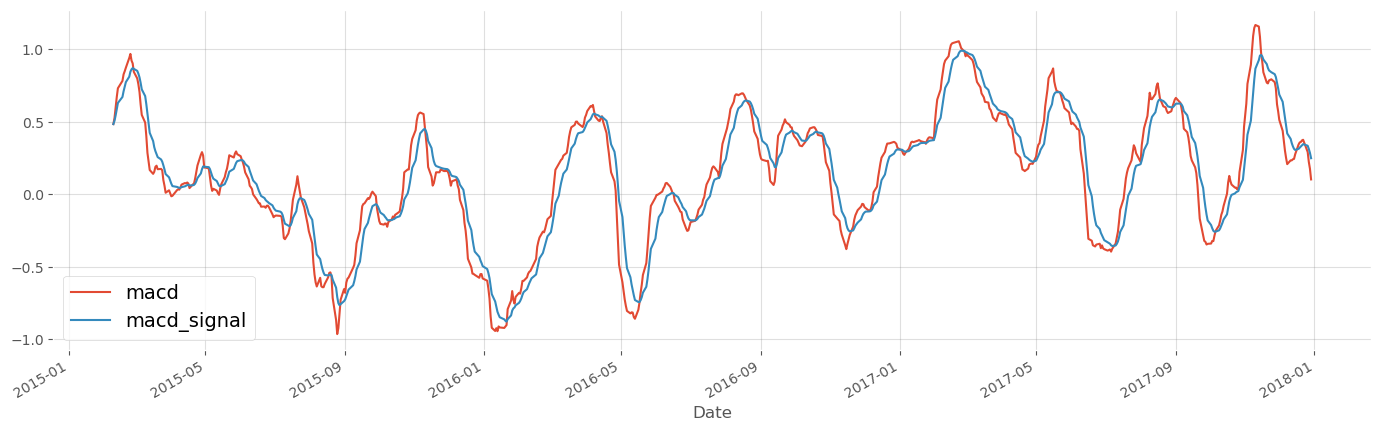

In [46]:
df_aapl["macd"].plot(figsize = [17, 5]
                    )

df_aapl["macd_signal"].plot()

plt.legend()
plt.show()

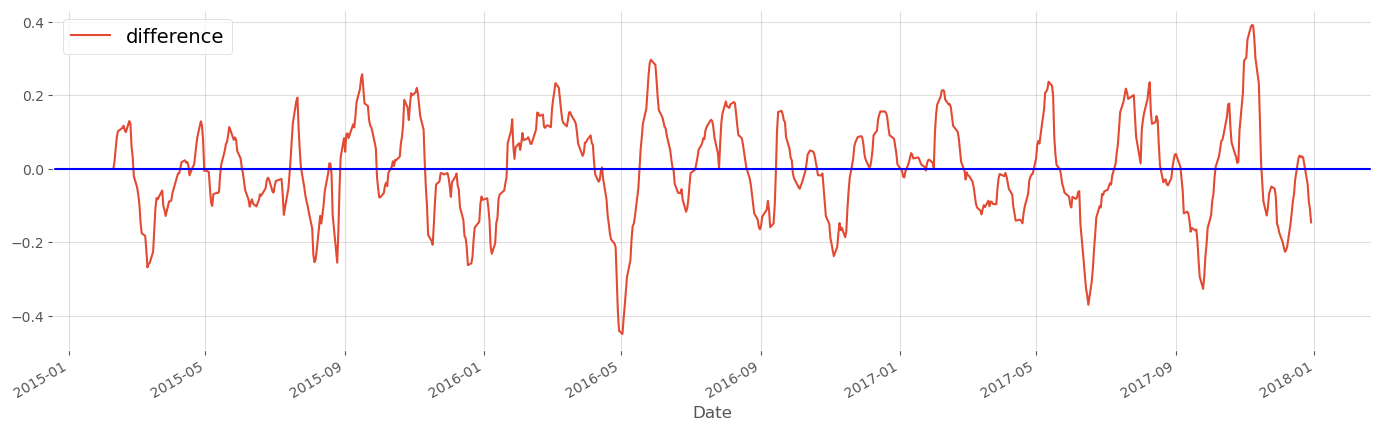

In [51]:
(
    df_aapl["macd"] - df_aapl["macd_signal"]
).plot(figsize = [17, 5],
       label = "difference"
      )

plt.axhline(0,
            color = "blue")

plt.legend()

In [52]:
%whos

Variable                     Type         Data/Info
---------------------------------------------------
alphas                       DataFrame                  Alphas A   <...>\n[1121 rows x 3 columns]
alphas_cumulative_returns    DataFrame                Alphas A  Alp<...>\n[1121 rows x 3 columns]
alphas_returns               DataFrame                Alphas A  Alp<...>\n[1121 rows x 3 columns]
answer_3                     list         n=3
answer_4                     list         n=3
answer_5                     list         n=3
c                            str          Longest Drawdown
calculate_cagr               function     <function calculate_cagr at 0x3270c13a0>
calculate_drawdown_percent   function     <function calculate_drawd<...>n_percent at 0x3270c14c0>
calculate_longest_drawdown   function     <function calculate_longe<...>_drawdown at 0x3270c1700>
calculate_sharpe_ratio       function     <function calculate_sharpe_ratio at 0x16fc80310>
df_aapl                      DataFr

In [53]:
df_aapl.columns

Index(['AAPL', 'ema_12', 'ema_26', 'macd', 'macd_signal'], dtype='object', name='Ticker')

In [54]:
df_aapl["difference"] =\
(
    df_aapl["macd"]
    -
    df_aapl["macd_signal"]
)

df_aapl.columns

Index(['AAPL', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'difference'], dtype='object', name='Ticker')

In [57]:
### Document --> add a vector into DF of position cross

df_aapl["position_crossing"] =\
(
    np
    .sign(df_aapl["difference"]
          * 
          df_aapl["difference"].shift(1)
         ) == -1
)

In [58]:
(
    df_aapl["position_crossing"]
    .value_counts()
)

position_crossing
False    712
True      43
Name: count, dtype: int64

### MACD Direction: Bullish vs. Bearish

In [59]:
df_aapl["position_macd_direction"] =\
(
    np
    .sign(df_aapl["macd"]
          .diff()
         )
)

In [60]:
df_aapl["position_macd_direction"].value_counts()

position_macd_direction
 1.0    365
-1.0    364
Name: count, dtype: int64

### <font color = green> NOTE: The MACD crossover strategy is defined as:

- A `bullish` crossover arises when the MACD line turns `upward and crosses` beyond the MACD signal line.
- A `bearish` crossover arises when the MACD line turns `downward and crosses` under the MACD signal line.

In [63]:
df_aapl

Ticker,AAPL,ema_12,ema_26,macd,macd_signal,difference,position_crossing,position_macd_direction
Date,,,,,,,,
2015-01-02,24.261044,NaN,NaN,NaN,NaN,NaN,False,NaN
2015-01-05,23.577572,NaN,NaN,NaN,NaN,NaN,False,NaN
2015-01-06,23.579794,NaN,NaN,NaN,NaN,NaN,False,NaN
2015-01-07,23.910435,NaN,NaN,NaN,NaN,NaN,False,NaN
2015-01-08,24.829130,NaN,NaN,NaN,NaN,NaN,False,NaN
...,...,...,...,...,...,...,...,...
2017-12-22,41.025661,40.689052,40.313682,0.375370,0.345253,0.030117,False,1.0
2017-12-26,39.984833,40.580710,40.289323,0.291388,0.334480,-0.043093,True,-1.0
2017-12-27,39.991856,40.490117,40.267288,0.222829,0.312150,-0.089321,False,-1.0


### `OOP`

In [ ]:
# class Indicator_MACD(Indicator):
#     def __init__(
#         self,
#         symbol: str,
#         price_data = pd.DataFrame,
#         short_period: int = 12,
#         long_period: int = 26,
#         signal_period: int = 9
#     ):
        

In [73]:
df_aapl["position_crossing"].value_counts()

position_crossing
False    712
True      43
Name: count, dtype: int64

#### <mark>Bullish???</mark>

In [89]:
bullish =\
(
    (df_aapl["position_macd_direction"] > 0) # condition A
    & # intersect
    df_aapl["position_crossing"] # condition B
)

#### <mark>Bearish???</mark>

In [90]:
bearish =\
(
    (df_aapl["position_macd_direction"] < 0) # condition A has to be modified
    & # intersect
    df_aapl["position_crossing"] # condition B
)

In [70]:
print(bullish.sum()
     )

21


In [71]:
print(bearish.sum()
     )

22


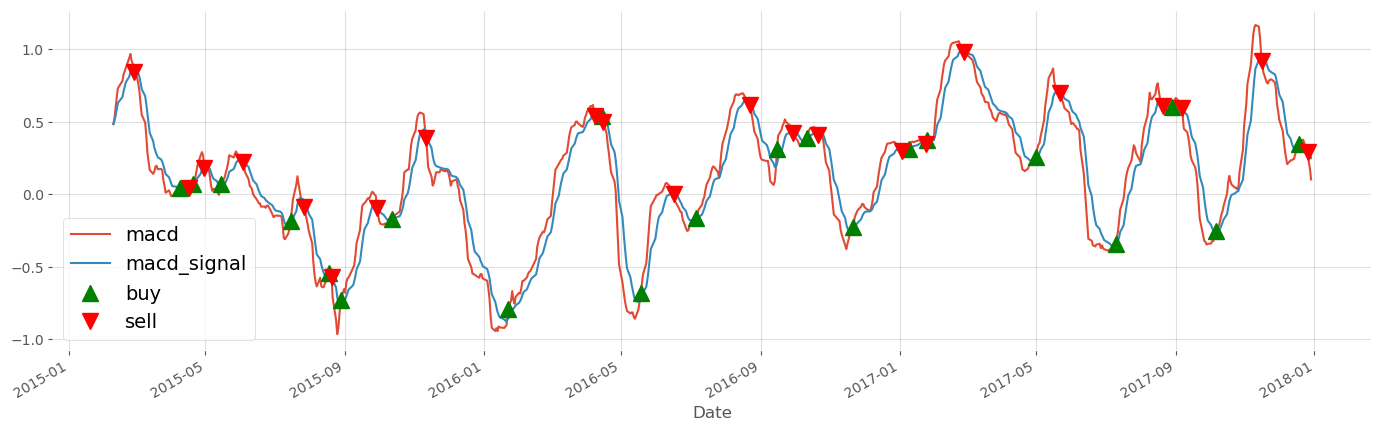

In [72]:
df_aapl["macd"].plot(figsize = [17,5]
                    )

df_aapl["macd_signal"].plot()

plt.plot(df_aapl["macd"].loc[bullish].index,
         df_aapl["macd"].loc[bullish],
         "g^",
         label = "buy",
         markersize = 11
        )

plt.plot(df_aapl["macd"].loc[bearish].index,
         df_aapl["macd"].loc[bearish],
         "rv",
         label = "sell",
         markersize = 11
        )


plt.legend() ### Hmmm....

## <mark>A Direct Solution :)</mark>

In [74]:
def download_price_data(
    ticker: str
    ) -> pd.DataFrame:
    return (
        yf
        .download(ticker,
                  start = "2015-01-01",
                  end = "2017-12-31")
        ["Close"]
    )

In [75]:
aapl = download_price_data("AAPL")

[*********************100%***********************]  1 of 1 completed


In [76]:
aapl

Ticker,AAPL
Date,
2015-01-02,24.261044
2015-01-05,23.577572
2015-01-06,23.579794
2015-01-07,23.910435
2015-01-08,24.829130
...,...
2017-12-22,41.025661
2017-12-26,39.984833
2017-12-27,39.991856


In [78]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


In [79]:
def compute_MACD(
    df: pd.DataFrame,
    span: list[int, int, int]
    ) -> pd.DataFrame:

    df[f"{span[0]}_ewma"] =\
    (
        df
        ["AAPL"]
        .ewm(span = span[0]
            )
        .mean()
    )

    df[f"{span[1]}_ewma"] =\
    (
        df
        ["AAPL"]
        .ewm(span = span[1]
            )
        .mean()
    )

    df["MACD"] =\
    (
        df
        .eval(
            "`12_ewma` - `26_ewma`"
        )
    )

    df["signal_line"] =\
    (
        df
        ["MACD"]
        .ewm(span = span[2]
            )
        .mean()
    )
    return df

In [81]:
compute_MACD(aapl, [12, 26, 9]
            )

Ticker,AAPL,12_ewma,26_ewma,MACD,signal_line
Date,,,,,
2015-01-02,24.261044,24.261044,24.261044,0.000000,0.000000
2015-01-05,23.577572,23.890830,23.906164,-0.015334,-0.008519
2015-01-06,23.579794,23.769432,23.788902,-0.019470,-0.013007
2015-01-07,23.910435,23.813941,23.822878,-0.008936,-0.011628
2015-01-08,24.829130,24.089764,24.056232,0.033533,0.001806
...,...,...,...,...,...
2017-12-22,41.025661,40.689052,40.313682,0.375370,0.345253
2017-12-26,39.984833,40.580710,40.289323,0.291388,0.334480
2017-12-27,39.991856,40.490117,40.267288,0.222829,0.312150


In [84]:
def generate_signal(
    df: pd.DataFrame
    ) -> pd.DataFrame:
    df["signal"] =\
    (
        np
        .where(
            (df["MACD"] > df["signal_line"])
            &
            (df["MACD"].shift(1) < df["signal_line"]
            ),
            1, np.nan
        )
    )

    df["signal"] =\
    (
        np
        .where(
            (df["MACD"] < df["signal_line"])
            &
            (df["MACD"].shift(1) > df["signal_line"]
            ),
            -1, df["signal"]
        )
    )

    df["trading_position"] =\
    (
        df
        ["signal"]
        .ffill()
        .fillna(0)
    )

    return df

In [85]:
%who

aapl	 alphas	 alphas_cumulative_returns	 alphas_returns	 answer_3	 answer_4	 answer_5	 bearish	 bullish	 
c	 calculate_cagr	 calculate_drawdown_percent	 calculate_longest_drawdown	 calculate_sharpe_ratio	 compute_MACD	 df_aapl	 df_for_ranking	 df_to_assess	 
dict_for_order	 dict_to_assess	 download_price_data	 dt	 generate_signal	 mpl	 np	 order	 pd	 
pdr	 plt	 test_df_to_assess	 this	 variable	 yf	 


In [86]:
generate_signal(aapl)

Ticker,AAPL,12_ewma,26_ewma,MACD,signal_line,signal,trading_position
Date,,,,,,,
2015-01-02,24.261044,24.261044,24.261044,0.000000,0.000000,NaN,0.0
2015-01-05,23.577572,23.890830,23.906164,-0.015334,-0.008519,-1.0,-1.0
2015-01-06,23.579794,23.769432,23.788902,-0.019470,-0.013007,NaN,-1.0
2015-01-07,23.910435,23.813941,23.822878,-0.008936,-0.011628,1.0,1.0
2015-01-08,24.829130,24.089764,24.056232,0.033533,0.001806,1.0,1.0
...,...,...,...,...,...,...,...
2017-12-22,41.025661,40.689052,40.313682,0.375370,0.345253,NaN,1.0
2017-12-26,39.984833,40.580710,40.289323,0.291388,0.334480,-1.0,-1.0
2017-12-27,39.991856,40.490117,40.267288,0.222829,0.312150,NaN,-1.0


### <mark>Christmas arrives early :) with a gift!</mark>

In [91]:
def gen_signal(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # gen signals for crossovers

    df["signal"] =\
    (
        np
        .select(
            [
                (df["MACD"] > df["signal_line"]) & (df["MACD"].shift(1) < df["signal_line"]), # 1
                (df["MACD"] < df["signal_line"]) & (df["MACD"].shift(1) > df["signal_line"]), # -1
            ],
            [1, -1],
            default = np.nan
        )
    )
    # team, we need to have where we can carry forward the last position,
    # sfhit to avoid (prevent) lookahead bias!!!
    df["trading_position"] =\
    (
        df["signal"]
        .ffill()
        .shift(1)
        .fillna(0)
    )

#### optinal choice of yours
    # threshold = 0.0
    # (df["MACD"] > df["signal_line"] + threshold) 
    # team, this will prevent flip-flopping around minor crossings (NOISE) !!!
    # it's all about the signal detection from noise!!!
    return df

In [92]:
gen_signal(aapl)

Ticker,AAPL,12_ewma,26_ewma,MACD,signal_line,signal,trading_position
Date,,,,,,,
2015-01-02,24.261044,24.261044,24.261044,0.000000,0.000000,NaN,0.0
2015-01-05,23.577572,23.890830,23.906164,-0.015334,-0.008519,-1.0,0.0
2015-01-06,23.579794,23.769432,23.788902,-0.019470,-0.013007,NaN,-1.0
2015-01-07,23.910435,23.813941,23.822878,-0.008936,-0.011628,1.0,-1.0
2015-01-08,24.829130,24.089764,24.056232,0.033533,0.001806,1.0,1.0
...,...,...,...,...,...,...,...
2017-12-22,41.025661,40.689052,40.313682,0.375370,0.345253,NaN,1.0
2017-12-26,39.984833,40.580710,40.289323,0.291388,0.334480,-1.0,1.0
2017-12-27,39.991856,40.490117,40.267288,0.222829,0.312150,NaN,-1.0


### <mark>NOTE: Just to confirm, team—we’re still in progress. The exact bullish crossover condition still needs an alignment fix (either shifting both indicators or using the histogram sign change), which we’ll cover further in the next PyDay consultation session. We’re also still waiting for our classmates’ submissions.</mark>

### Below are the lines of code that lead to an answer:

### <font color = blue> 👉 Question 9</font>. Let’s suppose that you started from a $100,000 capital base for the given security.

### Given a $5 fixed commission fee per trade, how much in cumulative returns could you have had as a result of the MACD crossover strategy?

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 9 </font>

    The answer is ____________ % .

### <font color = blue> 👉 Question 10</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 10 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

### <font color = blue> 👉 Question 11</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 11 </font>

    Below average year(s) : ____________ 
    
    Above average year(s) : ____________ 
     

###  <font color = blue> 👉 Question 12. </font> What's the annualized Sharpe ratio of the current investment strategy?

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 12 </font>
    
    Sharpe ratio: __________
    

### <font color="green">"💯 Thank you for putting your efforts into the exercise problem sets 😊"</font>